# Geospatial Data Analytics Notebook
This notebook introduces core geospatial workflows using GeoPandas and Shapely, then applies them to New York City neighborhood and population datasets.

## What this notebook covers
- Environment setup and geospatial geometry basics
- GeoDataFrame creation and visualization
- Coordinate reference systems (CRS) and reprojection
- Overlay and attribute enrichment with demographic data
- Buffer-based population analysis and point conversion
- Initial exploration of NYC street tree data

In [1]:
%pip install geopandas
%pip install matplotlib
%pip install shapely

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Import Libraries
Load the core Python packages used throughout the notebook.

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import pandas as pd

In [3]:
from shapely.geometry import Point, LineString, Polygon, MultiPolygon

## 2. Build Basic Geometries
Create simple geometric objects and combine them to understand spatial operations in Shapely.

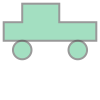

In [4]:
# Define the top of the car
top = Polygon([(0, 1), (0, 2), (2, 2), (2, 1)])
top

# Define the bottom part of the car
bottom = Polygon([(-1, 0), (-1, 1), (4, 1), (4, 0)])
bottom

# Create the wheels with a radius of 0.5 each
wheel_front = Point(0, -0.5).buffer(0.5)
wheel_rear = Point(3, -0.5).buffer(0.5)
wheel_rear

# Combine the shapes to form the car
car = top.union(bottom).union(wheel_front).union(wheel_rear)
car

# Calculate the circumference and area of the car


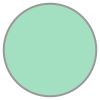

In [5]:
point = Point(0, 0)
point

circle = point.buffer(1)
circle

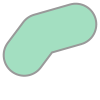

In [6]:
line = LineString([(2,2), (3.5,4), (7,5)])
line

line_buffer = line.buffer(2)
line_buffer

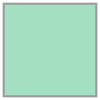

In [7]:
square = Polygon([(3, 0), (3, 1), (4, 1), (4, 0)])
square

## 3. Create and Enrich a GeoDataFrame
Collect geometries into a GeoDataFrame, derive attributes, and compute basic geometric metrics.

In [8]:
geodata = {'point':point, 'circle':circle, 'line':line, 'line_buffer':line_buffer, 'square':square}

geodata.keys()

dict_keys(['point', 'circle', 'line', 'line_buffer', 'square'])

In [9]:
geodata.values()

dict_values([<POINT (0 0)>, <POLYGON ((1 0, 0.995 -0.098, 0.981 -0.195, 0.957 -0.29, 0.924 -0.383, 0.882...>, <LINESTRING (2 2, 3.5 4, 7 5)>, <POLYGON ((1.9 5.2, 2.018 5.343, 2.149 5.474, 2.291 5.593, 2.444 5.698, 2.60...>, <POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))>])

In [10]:
gdf = gpd.GeoDataFrame(geodata.items(), columns = ['geo_name', 'geometry'])
gdf

,geo_name,geometry
0,point,POINT (0 0)
1,circle,"POLYGON ((1 0, 0.99518 -0.09802, 0.98079 -0.19..."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)"
3,line_buffer,"POLYGON ((1.9 5.2, 2.01797 5.34298, 2.14867 5...."
4,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))"


In [11]:
gdf['geometry_type'] = gdf['geometry'].apply(lambda x: type(x).__name__)
gdf

,geo_name,geometry,geometry_type
0,point,POINT (0 0),Point
1,circle,"POLYGON ((1 0, 0.99518 -0.09802, 0.98079 -0.19...",Polygon
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString
3,line_buffer,"POLYGON ((1.9 5.2, 2.01797 5.34298, 2.14867 5....",Polygon
4,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon


In [12]:
gdf['geometry_buffered'] = gdf['geometry'].apply(lambda x: x.buffer(0.5))
gdf

,geo_name,geometry,geometry_type,geometry_buffered
0,point,POINT (0 0),Point,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0...."
1,circle,"POLYGON ((1 0, 0.99518 -0.09802, 0.98079 -0.19...",Polygon,"POLYGON ((1.4994 0.02453, 1.4994 -0.02453, 1.4..."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString,"POLYGON ((3.1 4.3, 3.12949 4.33574, 3.16217 4...."
3,line_buffer,"POLYGON ((1.9 5.2, 2.01797 5.34298, 2.14867 5....",Polygon,"POLYGON ((1.5 5.5, 1.51433 5.51821, 1.6323 5.6..."
4,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon,"POLYGON ((3 -0.5, 2.95099 -0.49759, 2.90245 -0..."


In [13]:
gdf['geometry_length'] = [g.length for g in gdf['geometry'].to_list()]
gdf['geometry_area'] = [g.area for g in gdf['geometry'].to_list()]

gdf

,geo_name,geometry,geometry_type,geometry_buffered,geometry_length,geometry_area
0,point,POINT (0 0),Point,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0....",0.000000,0.000000
1,circle,"POLYGON ((1 0, 0.99518 -0.09802, 0.98079 -0.19...",Polygon,"POLYGON ((1.4994 0.02453, 1.4994 -0.02453, 1.4...",6.280662,3.136548
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString,"POLYGON ((3.1 4.3, 3.12949 4.33574, 3.16217 4....",6.140055,0.000000
3,line_buffer,"POLYGON ((1.9 5.2, 2.01797 5.34298, 2.14867 5....",Polygon,"POLYGON ((1.5 5.5, 1.51433 5.51821, 1.6323 5.6...",24.793406,37.056992
4,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon,"POLYGON ((3 -0.5, 2.95099 -0.49759, 2.90245 -0...",4.000000,1.000000


<Axes: >

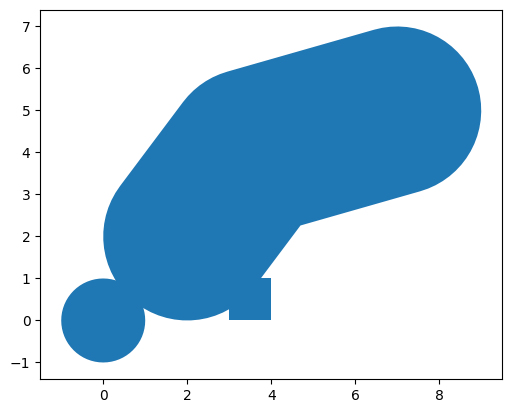

In [14]:
gdf.plot()

## 4. Visualize Synthetic Geometry Data
Use progressively customized maps to understand how styling choices affect interpretation.

<Axes: >

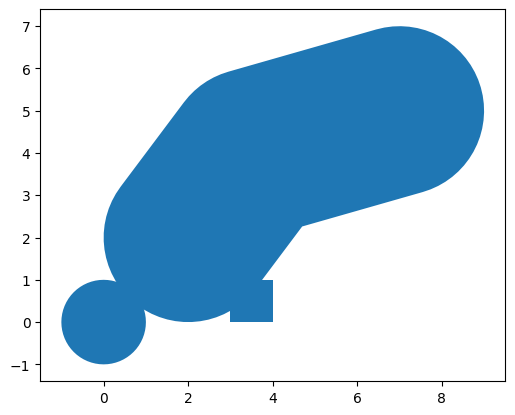

In [15]:
f, ax = plt.subplots(1,1,figsize=(6,6))

gdf.plot(ax=ax)

<Axes: >

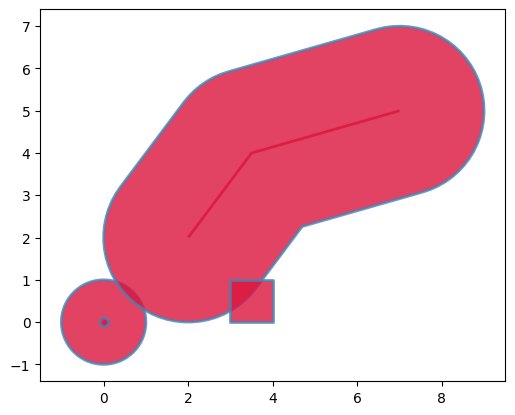

In [16]:
f, ax = plt.subplots(1,1,figsize=(6,6))
gdf.plot(ax=ax,
        color = 'crimson',
        edgecolor = 'steelblue',
        linewidth = 2,
        alpha = 0.8)

<Axes: >

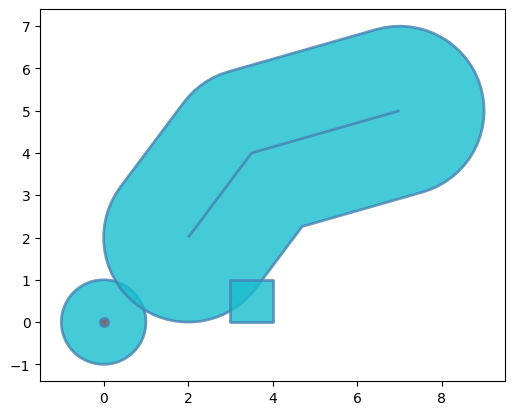

In [17]:
f, ax = plt.subplots(1,1,figsize=(6,6))

gdf.plot(ax=ax,
        column = 'geometry_type',
        edgecolor = 'steelblue',
        linewidth = 2,
        alpha = 0.8)

In [18]:
%pip install geodatasets
from geodatasets import get_path
gdf = gpd.read_file(get_path("nybb"))
gdf

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


## 5. Load NYC Borough Boundaries
Switch from synthetic examples to real geospatial boundaries from the NYC borough dataset.

<Axes: >

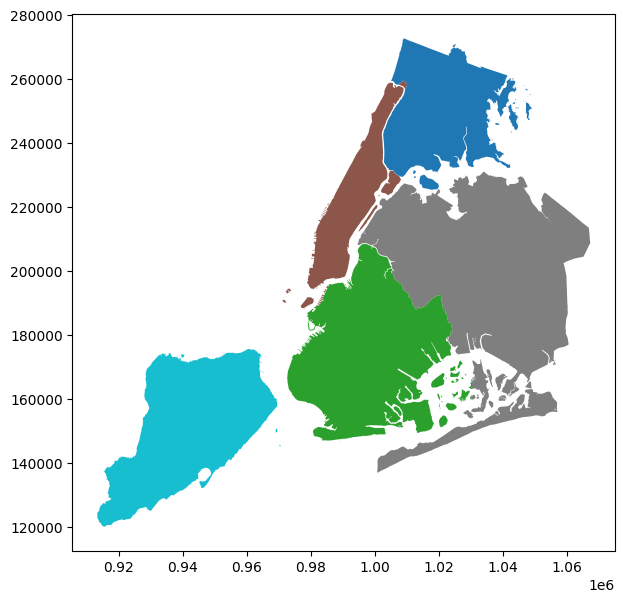

In [19]:
f, ax = plt.subplots(1,1,figsize=(7,7))
gdf.plot(ax=ax, column = 'BoroName', linewidth = 1.5, cmap = 'tab10')

(np.float64(905464.7390380859),
 np.float64(1075092.8783935546),
 np.float64(112485.76063504723),
 np.float64(280480.4142594267))

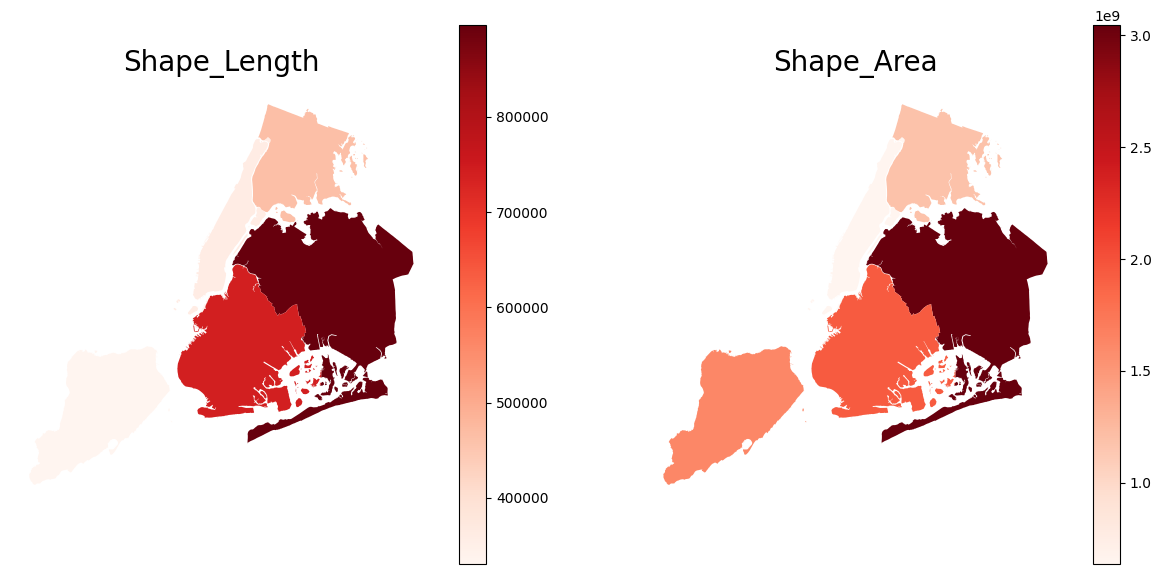

In [20]:
f, ax = plt.subplots(1,2,figsize=(15,7))

gdf.plot(column = 'Shape_Leng', ax = ax[0], cmap = 'Reds', legend = True)
gdf.plot(column = 'Shape_Area', ax = ax[1], cmap = 'Reds', legend = True)

ax[0].set_title('Shape_Length', fontsize = 20, pad = 10)
ax[1].set_title('Shape_Area', fontsize = 20, pad = 10)

ax[0].axis('off')
ax[1].axis('off')

In [21]:
nybb = gpd.read_file(get_path("nybb"))
print(nybb.crs)

EPSG:2263


## 6. Coordinate Reference Systems (CRS)
Inspect CRS metadata and reproject geometries before comparative or global-coordinate analysis.

In [22]:
nybb.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [23]:
world_nybb = nybb.to_crs('4326')
print(world_nybb.crs)

EPSG:4326


<Axes: >

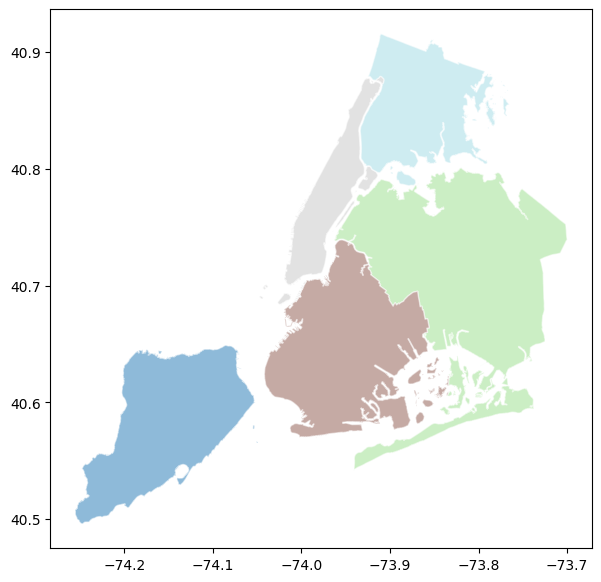

In [24]:
f, ax = plt.subplots(1,1,figsize=(7,7))
world_nybb.plot(ax=ax, edgecolor = 'w', cmap = 'tab20', alpha = 0.5, linewidth = 1)

In [27]:
file_name = '2010 Neighborhood Tabulation Areas (NTAs).geojson'
gdf_NTA = gpd.read_file(file_name)
print(len(gdf_NTA))
gdf_NTA.head(10)

195


,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ..."
1,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ..."
2,BX41,14716710.849,005,Mount Hope,18937.2480746,Bronx,2,"MULTIPOLYGON (((-73.89561 40.85457, -73.89662 ..."
3,BK68,16482821.6487,047,Fort Greene,19825.5208594,Brooklyn,3,"MULTIPOLYGON (((-73.96939 40.69608, -73.96938 ..."
4,QN38,38835920.1944,081,Pomonok-Flushing Heights-Hillcrest,30731.4196253,Queens,4,"MULTIPOLYGON (((-73.7964 40.73828, -73.79639 4..."
5,QN52,29453683.8069,081,East Flushing,25848.5455105,Queens,4,"MULTIPOLYGON (((-73.79493 40.7578, -73.79475 4..."
6,BK44,27379161.6062,047,Madison,26237.2579388,Brooklyn,3,"MULTIPOLYGON (((-73.93754 40.60856, -73.9383 4..."
7,QN01,39971928.8627,081,South Jamaica,32122.5522563,Queens,4,"MULTIPOLYGON (((-73.77396 40.69981, -73.77446 ..."
8,QN07,22887773.3849,081,Hollis,20976.3359208,Queens,4,"MULTIPOLYGON (((-73.75726 40.71814, -73.75589 ..."
9,BK77,24927927.3355,047,Bushwick North,26321.6271006,Brooklyn,3,"MULTIPOLYGON (((-73.9014 40.69159, -73.90189 4..."


## 7. Compare Borough and Neighborhood Layers
Load neighborhood polygons, inspect their distribution, and prepare them for spatial comparison with borough boundaries.

Text(0.5, 1.0, 'NYC neighborhood length')

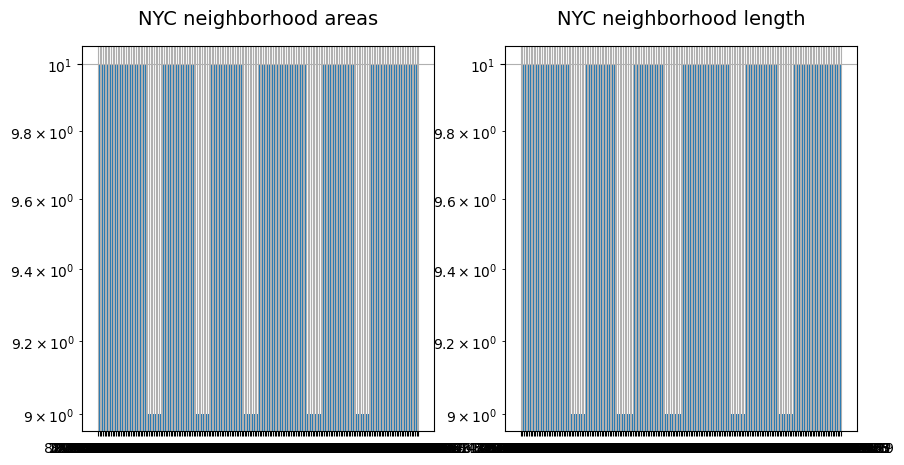

In [28]:
f, ax = plt.subplots(1,2,figsize=(10,5))
gdf_NTA.shape_area.hist(ax=ax[0], bins = 20)
gdf_NTA.shape_leng.hist(ax=ax[1], bins = 20)
ax[0].set_yscale('log')
ax[1].set_yscale('log')

ax[0].set_title('NYC neighborhood areas', fontsize = 14, pad = 16)
ax[1].set_title('NYC neighborhood length', fontsize = 14, pad = 16)

Text(0.5, 1.0, 'NYC neigbhorhoods')

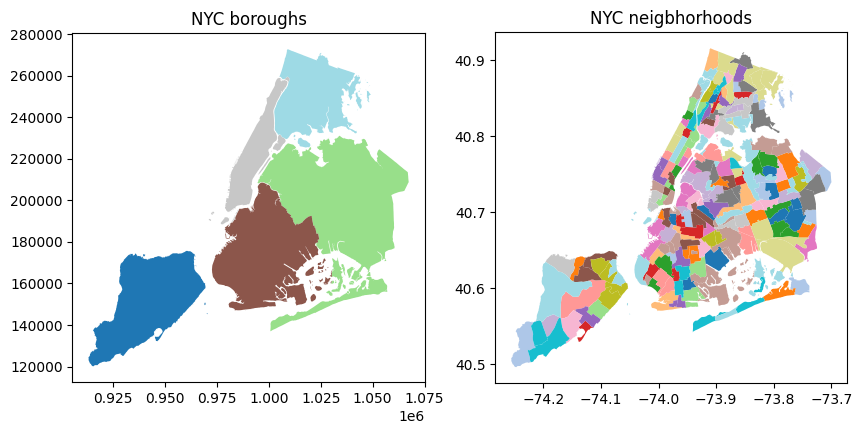

In [29]:
f, ax = plt.subplots(1,2,figsize=(10,5))

nybb.plot(ax=ax[0], cmap = 'tab20')
gdf_NTA.plot(ax=ax[1], cmap = 'tab20')

ax[0].set_title('NYC boroughs')
ax[1].set_title('NYC neigbhorhoods')

In [30]:
print(nybb.crs)
print(gdf_NTA.crs)

EPSG:2263
EPSG:4326


In [31]:
gdf_NTA_local = gdf_NTA.to_crs(nybb.crs)
print(gdf_NTA_local.crs)

EPSG:2263


### Key Analysis: Overlay-Based Neighborhood Counts
This block compares two counting strategies: direct borough grouping versus counts derived from polygon overlays. It also checks agreement using correlation.

In [32]:
df_group_1 = gdf_NTA_local.groupby(by = 'boro_name').count()[['geometry']].rename(columns = {'geometry' : 'ngh_cnt_1'})
df_group_1

gdf_over = gpd.overlay(nybb, gdf_NTA_local[['ntaname', 'geometry']])
gdf_over.head(3)


df_group_2 = gdf_over.groupby(by = 'BoroName').count()
df_group_2 = df_group_2[['ntaname']].rename(columns = {'ntaname' : 'ngh_cnt_2'})
df_group_2

df_group = df_group_1.merge(df_group_2, left_index = True, right_index = True)
df_group


df_group.corr()

,ngh_cnt_1,ngh_cnt_2
ngh_cnt_1,1.000000,0.984094
ngh_cnt_2,0.984094,1.000000


<Axes: >

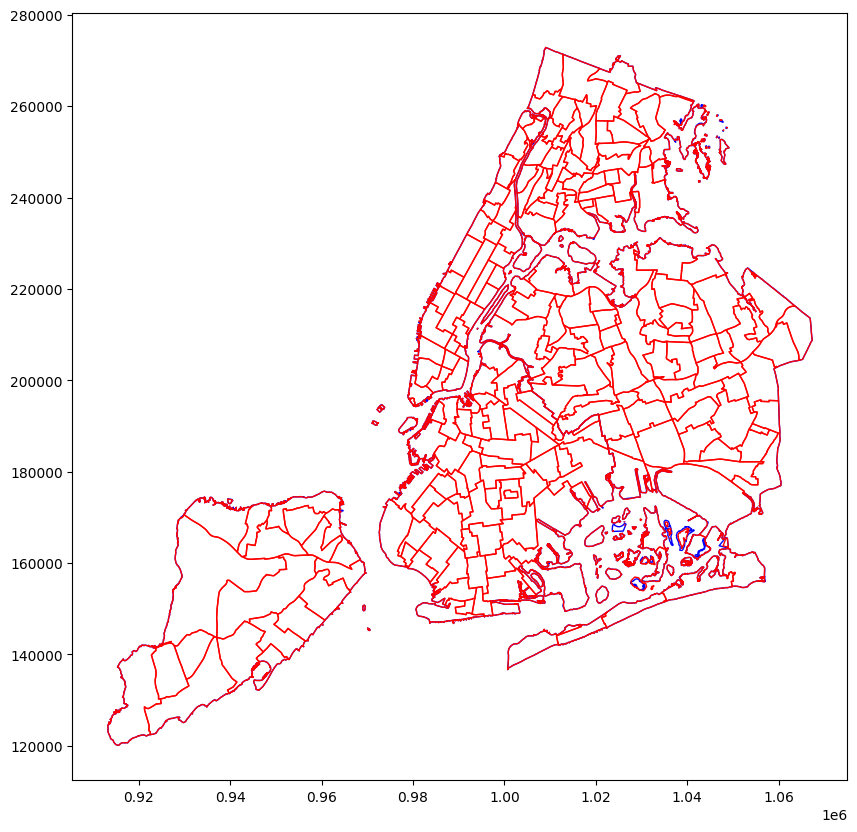

In [33]:
f, ax = plt.subplots(1,1,figsize=(10,10))
nybb.plot(ax=ax, color = 'none', edgecolor = 'b')
gdf_NTA_local.plot(ax=ax, color = 'none', edgecolor = 'r')

In [34]:
NY_NTA = pd.read_csv('New_York_City_Population_By_Neighborhood_Tabulation_Areas_20240618.csv')
NY_NTA.head()

gdf_NTA = gpd.read_file('2010 Neighborhood Tabulation Areas (NTAs).geojson')
print(len(gdf_NTA))

195


## 8. Enrich Neighborhood Geometry with Population Data
Join tabular demographics to neighborhood polygons and create a choropleth map of population.

In [35]:
print(set(NY_NTA.Year))
NY_NTA = NY_NTA[NY_NTA.Year==2010]

display(NY_NTA.head(1))
display(gdf_NTA.head(1))

{2000, 2010}


,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
195,Bronx,2010,5,BX01,Claremont-Bathgate,31078


,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ..."


In [36]:
codes_1 = set(NY_NTA['NTA Code'])
codes_2 = set(gdf_NTA['ntacode'])

In [37]:
len(codes_1), len(codes_2), len(codes_1.intersection(codes_2))

(195, 195, 195)

In [38]:
gdf_merged = gdf_NTA.merge(NY_NTA, right_on = 'NTA Code', left_on = 'ntacode')
# gdf_merged = gdf_merged[['ntacode', 'geometry', 'Population']]
gdf_merged.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2010,81,QN08,St. Albans,48593
1,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ...",Brooklyn,2010,47,BK50,Canarsie,83693
2,BX41,14716710.849,005,Mount Hope,18937.2480746,Bronx,2,"MULTIPOLYGON (((-73.89561 40.85457, -73.89662 ...",Bronx,2010,5,BX41,Mount Hope,51807


(np.float64(-74.28337047814922),
 np.float64(-73.67222994821337),
 np.float64(40.47516404814219),
 np.float64(40.93650271647436))

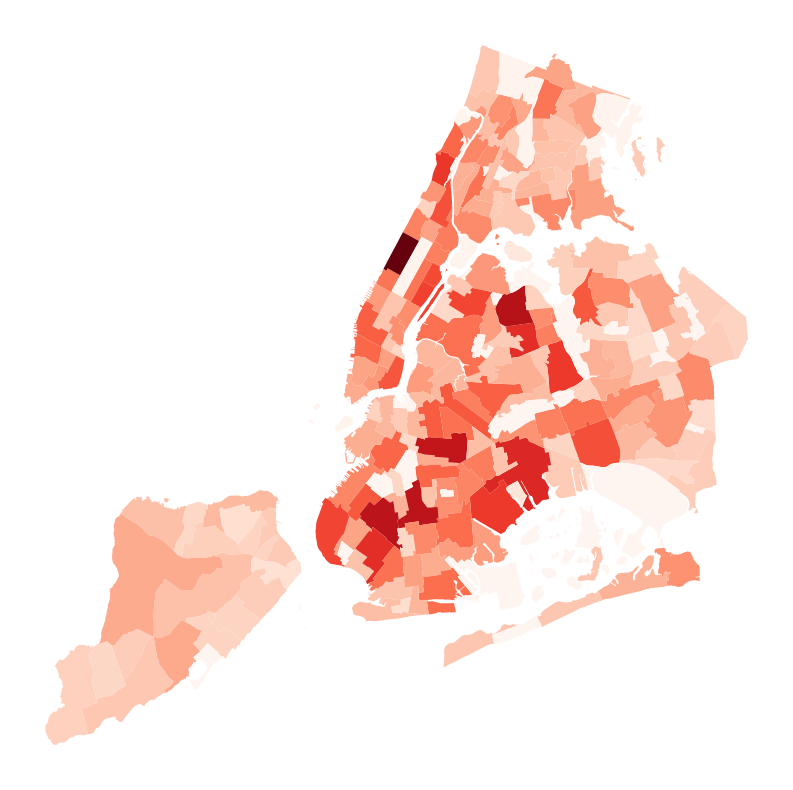

In [39]:
f, ax = plt.subplots(1,1,figsize=(10,10))

gdf_merged.plot(ax=ax, column = 'Population', cmap = 'Reds')
ax.axis('off')

In [40]:
gdf_Queens = gdf_merged[gdf_merged.boro_name=='Queens']
print(len(gdf_Queens))

58


## 9. Buffer Analysis Around Queens
Create neighborhood centroids and estimate how population exposure changes with increasing buffer distance.

In [41]:
distances = [100, 1000, 5000]
for d in distances:
    gdf_Queens.buffer(d)


C:\Users\Yasir\AppData\Local\Temp\ipykernel_38696\107387627.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_Queens.buffer(d)


In [42]:
gdf_merged_points = gdf_merged.copy()
gdf_merged_points['geometry'] = [g.centroid for g in list(gdf_merged_points.geometry)]
gdf_merged_points.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,POINT (-73.76315 40.6912),Queens,2010,81,QN08,St. Albans,48593
1,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,POINT (-73.89975 40.63804),Brooklyn,2010,47,BK50,Canarsie,83693
2,BX41,14716710.849,005,Mount Hope,18937.2480746,Bronx,2,POINT (-73.90512 40.84906),Bronx,2010,5,BX41,Mount Hope,51807


<Axes: >

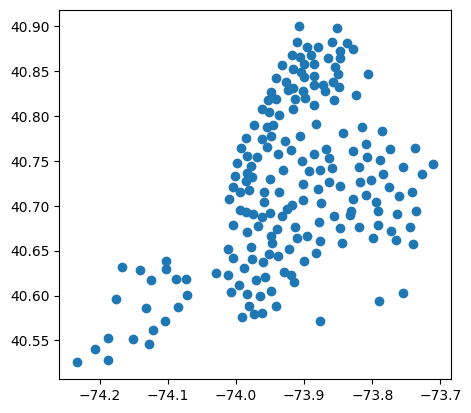

In [43]:
gdf_merged_points.plot()

In [44]:
def count_population_stats(distance):
    
    # buffering
    gdf_Queens_buffered = gdf_Queens.copy()
    gdf_Queens_buffered['geometry'] = gdf_Queens_buffered['geometry'].buffer(distance)
    gdf_Queens_buffered.plot()
    
    
    # spatial join
    gdf_joined = gpd.sjoin(gdf_merged_points, gdf_Queens_buffered)
    
    
    # compute population
    print('Zone size: ', distance, ' feet')
    print('Queens population: ', sum(gdf_joined.Population_left))
    print('Buffer zone population: ', sum(gdf_joined.Population_right))
    print('Population ratio: ', round(sum(gdf_joined.Population_left) / sum(gdf_joined.Population_right),2))
    print()

### Key Analysis: Population Ratio by Buffer Distance
The function below buffers Queens neighborhoods, performs a spatial join, and reports the ratio between nearby population and baseline Queens population.

C:\Users\Yasir\AppData\Local\Temp\ipykernel_38696\2702623745.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_Queens_buffered['geometry'] = gdf_Queens_buffered['geometry'].buffer(distance)


Zone size:  100  feet
Queens population:  474157714
Buffer zone population:  434990790
Population ratio:  1.09



C:\Users\Yasir\AppData\Local\Temp\ipykernel_38696\2702623745.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_Queens_buffered['geometry'] = gdf_Queens_buffered['geometry'].buffer(distance)


Zone size:  1000  feet
Queens population:  474157714
Buffer zone population:  434990790
Population ratio:  1.09



C:\Users\Yasir\AppData\Local\Temp\ipykernel_38696\2702623745.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_Queens_buffered['geometry'] = gdf_Queens_buffered['geometry'].buffer(distance)


Zone size:  5000  feet
Queens population:  474157714
Buffer zone population:  434990790
Population ratio:  1.09



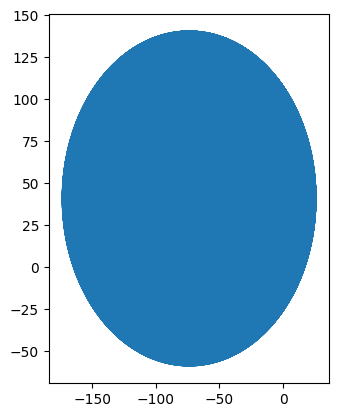

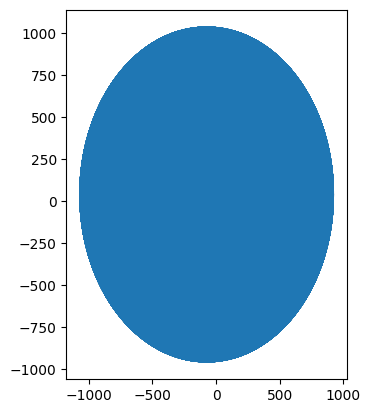

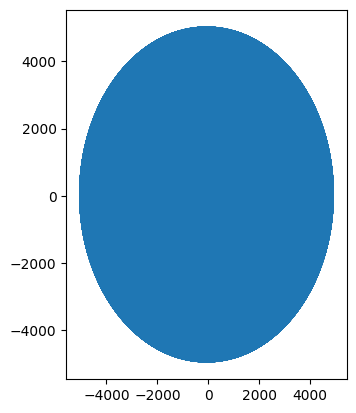

In [45]:
for distance in distances:
    count_population_stats(distance)

## 10. Geometry Feature Engineering Refresher
Rebuild a small synthetic geometry dataset, compute shape metrics, and style a thematic map using derived geometry attributes.

,geometry
0,"POLYGON ((0 1, 0 2, 2 2, 2 1, 0 1))"
1,"POLYGON ((-1 0, -1 1, 4 1, 4 0, -1 0))"
2,"POLYGON ((0.5 -0.5, 0.49759 -0.54901, 0.49039 ..."
3,"POLYGON ((3.5 -0.5, 3.49759 -0.54901, 3.49039 ..."


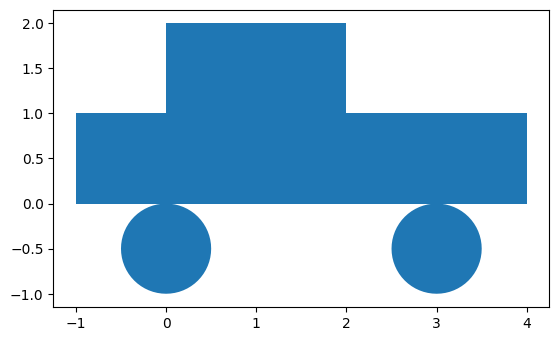

In [46]:
top = Polygon([(0,1),(0,2),(2,2),(2,1)])
bottom = Polygon([(-1,0),(-1,1),(4,1),(4,0)])
wheel_front = Point(0, -0.5).buffer(0.5)
wheel_rear = Point(3, -0.5).buffer(0.5)
geometries = [top, bottom, wheel_front, wheel_rear]
gdf = gpd.GeoDataFrame(geometries, columns = ['geometry'])
gdf.plot()
gdf.crs = 4326
display(gdf)

In [47]:
gdf['geometry_length'] = gdf.length
gdf['geometry_area'] = gdf.area
gdf.head()

C:\Users\Yasir\AppData\Local\Temp\ipykernel_38696\12644578.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['geometry_length'] = gdf.length
C:\Users\Yasir\AppData\Local\Temp\ipykernel_38696\12644578.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['geometry_area'] = gdf.area


,geometry,geometry_length,geometry_area
0,"POLYGON ((0 1, 0 2, 2 2, 2 1, 0 1))",6.000000,2.000000
1,"POLYGON ((-1 0, -1 1, 4 1, 4 0, -1 0))",12.000000,5.000000
2,"POLYGON ((0.5 -0.5, 0.49759 -0.54901, 0.49039 ...",3.140331,0.784137
3,"POLYGON ((3.5 -0.5, 3.49759 -0.54901, 3.49039 ...",3.140331,0.784137


In [48]:
gdf['geometry'] = [g.buffer(0.2) for g in gdf['geometry']]
gdf.head()

,geometry,geometry_length,geometry_area
0,"POLYGON ((0 0.8, -0.0196 0.80096, -0.03902 0.8...",6.000000,2.000000
1,"POLYGON ((-1 -0.2, -1.0196 -0.19904, -1.03902 ...",12.000000,5.000000
2,"POLYGON ((0.69976 -0.49019, 0.69976 -0.50981, ...",3.140331,0.784137
3,"POLYGON ((3.69976 -0.49019, 3.69976 -0.50981, ...",3.140331,0.784137


<Axes: >

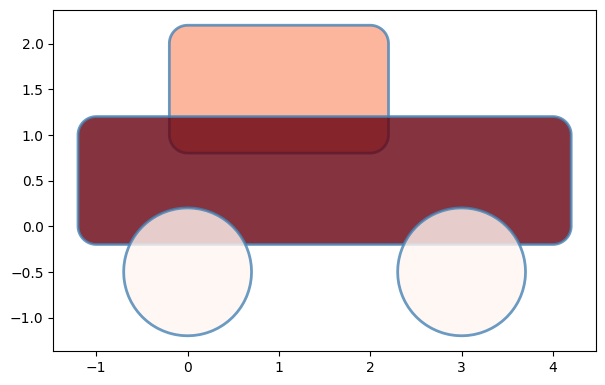

In [49]:
f, ax = plt.subplots(1, 1, figsize=(7, 7))

gdf.plot(column='geometry_length', ax=ax, cmap='Reds', edgecolor='steelblue', linewidth=2, alpha=0.8)


# Turning tabular data into geospatial


In [50]:
tdf = pd.read_csv('2015_Street_Tree_Census_-_Tree_Data_20240618.csv', nrows = 10000)
len(tdf)
tdf.head(3)

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,4073900,New York,40.723092,-73.844215,1027431.148,202756.7687,29.0,739.0,4052307.0,4.022210e+09
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,...,4097300,New York,40.794111,-73.818679,1034455.701,228644.8374,19.0,973.0,4101931.0,4.044750e+09
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3044900,New York,40.717581,-73.936608,1001822.831,200716.8913,34.0,449.0,3338310.0,3.028870e+09


In [51]:
geometry = [Point(xy) for xy in zip(tdf['longitude'], tdf['latitude'])]
geometry[0]

gdf = gpd.GeoDataFrame(tdf, geometry = geometry)[['tree_id', 'stump_diam', 'status', 'health', 'geometry']]
gdf.crs = 4326
gdf.head()

,tree_id,stump_diam,status,health,geometry
0,180683,0,Alive,Fair,POINT (-73.84422 40.72309)
1,200540,0,Alive,Fair,POINT (-73.81868 40.79411)
2,204026,0,Alive,Good,POINT (-73.93661 40.71758)
3,204337,0,Alive,Good,POINT (-73.93446 40.71354)
4,189565,0,Alive,Good,POINT (-73.97598 40.66678)


### Visualize Street Tree Status
Plot sampled street-tree points by status to inspect spatial patterns and data completeness in the tabular-to-geospatial conversion output.

(np.float64(-74.2791066075),
 np.float64(-73.68647660250001),
 np.float64(40.4790767395),
 np.float64(40.926552350499996))

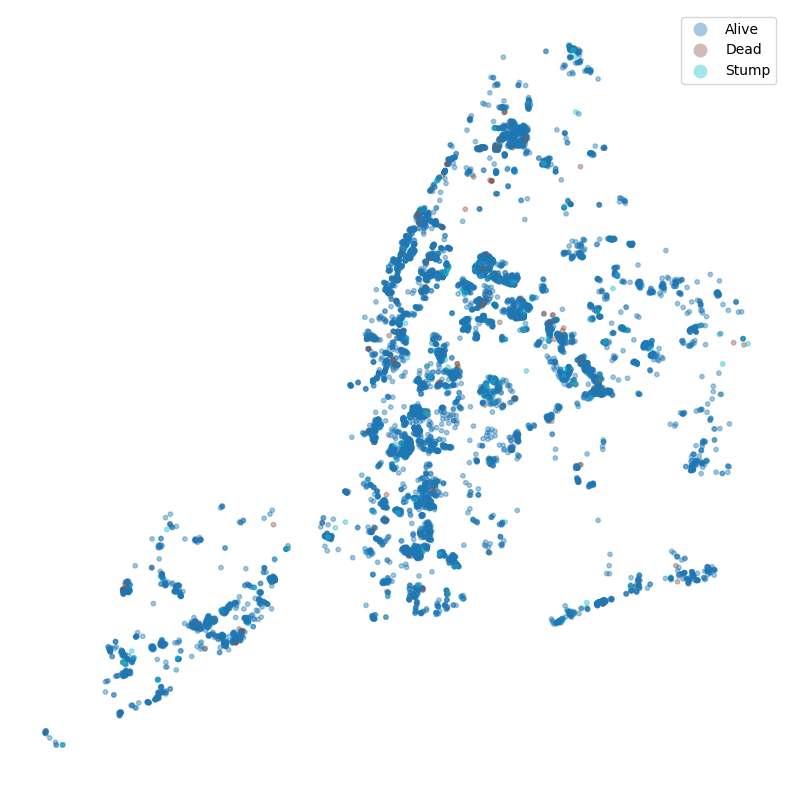

In [52]:
f, ax = plt.subplots(1,1,figsize=(10,10))

gdf.plot(ax=ax, column = 'status', legend = True, markersize = 10, alpha = 0.4)
ax.axis('off')

## 11. Spatially Join Trees to Neighborhoods
Attach tree points to neighborhood polygons, then prepare the joined records for neighborhood-level aggregation.

In [53]:
gdf_join = gpd.sjoin(gdf_merged, gdf)
gdf_join.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population,index_right,tree_id,stump_diam,status,health
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2010,81,QN08,St. Albans,48593,3004,147003,0,Alive,Good
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2010,81,QN08,St. Albans,48593,9227,146045,0,Alive,Fair
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2010,81,QN08,St. Albans,48593,726,147009,0,Alive,Fair


In [54]:
gdf_join = gdf_join[['NTA Name', 'Population', 'tree_id', 'geometry']]
gdf_join.head(3)

,NTA Name,Population,tree_id,geometry
0,St. Albans,48593,147003,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ..."
0,St. Albans,48593,146045,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ..."
0,St. Albans,48593,147009,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ..."


### Aggregate Tree Counts and Compute Per-Capita Rates
Count unique trees per neighborhood, merge counts back to polygons, and compute `trees_per_capita` for comparability across neighborhoods.

In [55]:
gdf_grouped = gdf_join.groupby(by = 'NTA Name').nunique()[['tree_id']]
gdf_grouped = gdf_grouped.rename(columns = {'tree_id' : 'tree_count'})
gdf_grouped

,tree_count
NTA Name,
Allerton-Pelham Gardens,2
Annadale-Huguenot-Prince's Bay-Eltingville,100
Arden Heights,131
Astoria,184
Auburndale,13
...,...
Yorkville,90
park-cemetery-etc-Bronx,2
park-cemetery-etc-Brooklyn,34


In [56]:
gdf_join_tree = gdf_merged.merge(gdf_grouped, left_on = 'NTA Name', right_index = True)
gdf_join_tree.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population,tree_count
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2010,81,QN08,St. Albans,48593,16
1,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ...",Brooklyn,2010,47,BK50,Canarsie,83693,13
2,BX41,14716710.849,005,Mount Hope,18937.2480746,Bronx,2,"MULTIPOLYGON (((-73.89561 40.85457, -73.89662 ...",Bronx,2010,5,BX41,Mount Hope,51807,126


In [57]:
gdf_join_tree['trees_per_capita'] = gdf_join_tree['tree_count'] / gdf_join_tree['Population']
gdf_join_tree = gdf_join_tree.sort_values(by = 'trees_per_capita', ascending = False)

In [61]:
gdf_join_tree[['NTA Name', 'tree_count', 'Population', 'trees_per_capita']].head(5)

,NTA Name,tree_count,Population,trees_per_capita
115,park-cemetery-etc-Brooklyn,34,418,0.081340
191,park-cemetery-etc-Manhattan,33,1849,0.017847
85,Oakwood-Oakwood Beach,286,22049,0.012971
77,Steinway,517,47534,0.010876
135,Kew Gardens,189,23278,0.008119


(np.float64(-74.28337047814922),
 np.float64(-73.67222994821337),
 np.float64(40.47516404814219),
 np.float64(40.93650271647436))

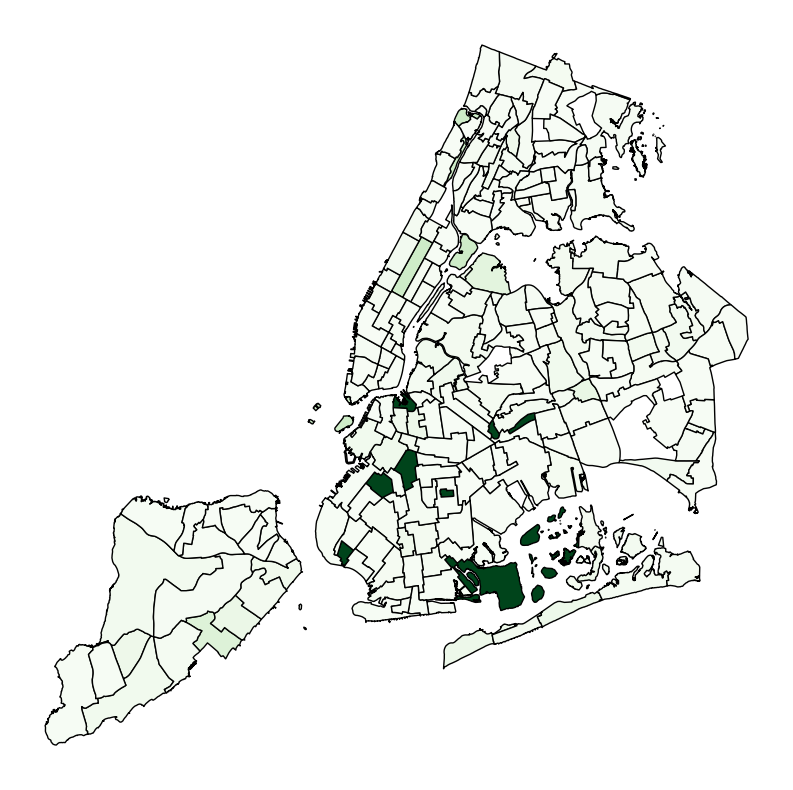

In [59]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1,1,figsize=(10,10))

gdf_join_tree.plot(ax=ax, column = 'trees_per_capita', cmap = 'Greens', edgecolor = 'k')

ax.axis('off')

### Improve Choropleth Readability with Log Scaling
Apply logarithmic color normalization to better separate neighborhoods with very small and very large `trees_per_capita` values.

(np.float64(-74.28337047814922),
 np.float64(-73.67222994821337),
 np.float64(40.47516404814219),
 np.float64(40.93650271647436))

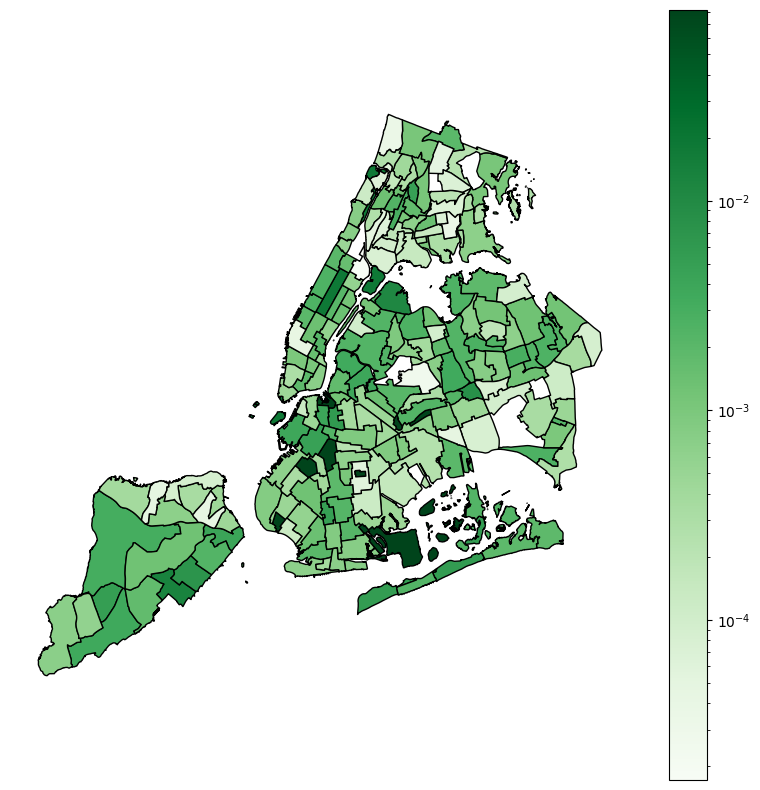

In [60]:
from matplotlib.colors import LogNorm

norm = LogNorm(vmin = gdf_join_tree['trees_per_capita'].min(), 
               vmax = gdf_join_tree['trees_per_capita'].max())


f, ax = plt.subplots(1,1,figsize=(10,10))

gdf_join_tree.plot(ax=ax, 
                   column = 'trees_per_capita', 
                   cmap = 'Greens', 
                   edgecolor = 'k',
                   norm = norm, 
                   legend = True)

ax.axis('off')